# 🏆 Ngày 5: Ultimate Forecasting Optimization (Synced v6)
Notebook này đã được đồng bộ với pipeline production trong `src/ultimate_ensemble_day5.py`.

**Mục tiêu:** chạy rolling-origin backtest (horizon 548), auto-chọn strategy tốt nhất, và xuất `submission_v6_day5_max_optimized.csv`.

## 1) Thư viện & cấu hình

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
HORIZON = 548

TRAIN_PATH = Path("../Data/processed_train.csv")
if not TRAIN_PATH.exists():
    TRAIN_PATH = Path("Data/processed_train.csv")

SUB_PATH = Path("../Data/sample_submission.csv")
if not SUB_PATH.exists():
    SUB_PATH = Path("Data/sample_submission.csv")

OUTPUT_PATH = Path("../submission_v6_day5_max_optimized.csv")
if not OUTPUT_PATH.parent.exists():
    OUTPUT_PATH = Path("submission_v6_day5_max_optimized.csv")

BACKTEST_REPORT_PATH = Path("../scratch/day5_backtest_report.csv")
if not BACKTEST_REPORT_PATH.parent.exists():
    BACKTEST_REPORT_PATH = Path("scratch/day5_backtest_report.csv")

print(f"TRAIN_PATH = {TRAIN_PATH}")
print(f"SUB_PATH = {SUB_PATH}")
print(f"OUTPUT_PATH = {OUTPUT_PATH}")
print(f"BACKTEST_REPORT_PATH = {BACKTEST_REPORT_PATH}")

TRAIN_PATH = ..\Data\processed_train.csv
SUB_PATH = ..\Data\sample_submission.csv
OUTPUT_PATH = ..\submission_v6_day5_max_optimized.csv
BACKTEST_REPORT_PATH = ..\scratch\day5_backtest_report.csv


## 2) Load dữ liệu

In [4]:
df_train = pd.read_csv(TRAIN_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
df_sub = pd.read_csv(SUB_PATH, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)

required_cols = {"Date", "Revenue", "COGS"}
missing = required_cols - set(df_train.columns)
if missing:
    raise ValueError(f"Missing required columns in training data: {missing}")

print("Train shape:", df_train.shape)
print("Submission shape:", df_sub.shape)
display(df_train.head(3))
display(df_train.tail(3))

Train shape: (3833, 31)
Submission shape: (548, 3)


,Date,Revenue,COGS,traffic,is_promo,total_stock,total_units_sold_lag1,month,day,dayofweek,...,cogs_lag_14,cogs_lag_30,revenue_roll_mean_7,revenue_roll_mean_30,cogs_roll_mean_7,cogs_roll_mean_30,days_to_tet,is_pre_tet,is_tet_week,is_post_tet
0,2012-07-04,5123547.94,3982991.19,0,0,NaN,0,7,4,3,...,0.0,0.0,0.0,0.0,0.0,0.0,999,0,0,0
1,2012-07-05,2751773.45,2150580.23,0,0,NaN,0,7,5,4,...,0.0,0.0,0.0,0.0,0.0,0.0,999,0,0,0
2,2012-07-06,3054029.42,2517632.84,0,0,NaN,0,7,6,5,...,0.0,0.0,0.0,0.0,0.0,0.0,999,0,0,0


,Date,Revenue,COGS,traffic,is_promo,total_stock,total_units_sold_lag1,month,day,dayofweek,...,cogs_lag_14,cogs_lag_30,revenue_roll_mean_7,revenue_roll_mean_30,cogs_roll_mean_7,cogs_roll_mean_30,days_to_tet,is_pre_tet,is_tet_week,is_post_tet
3830,2022-12-29,3083944.33,3170787.10,14640,1,95003.0,0,12,29,4,...,1554407.68,2694391.19,1.925798e+06,1.599323e+06,1.956326e+06,1.635268e+06,999,0,0,0
3831,2022-12-30,2884668.76,3022292.15,13713,1,95003.0,0,12,30,5,...,1521540.05,1346354.39,2.110416e+06,1.616831e+06,2.155892e+06,1.651148e+06,999,0,0,0
3832,2022-12-31,2383037.48,2279288.13,15512,1,104235.0,0,12,31,6,...,1321522.92,1683082.90,2.308053e+06,1.669063e+06,2.373471e+06,1.707013e+06,999,0,0,0


## 3) Hàm pipeline (sync với script production)

In [6]:
LEGACY_FEATURES = [
    "month", "day", "dayofweek", "is_weekend", "is_payday", "is_double_day",
    "traffic", "is_promo", "total_units_sold_lag1",
    "revenue_lag_1", "revenue_lag_7", "revenue_lag_14", "revenue_lag_30",
    "revenue_roll_mean_7", "revenue_roll_mean_30",
    "sin_year", "cos_year", "is_pre_tet", "is_tet_week", "is_post_tet"
]

DETRENDED_FEATURES = [
    "month", "day", "dayofweek", "is_weekend", "is_holiday",
    "days_to_tet", "is_pre_tet", "is_tet_week", "is_post_tet"
]

TET_DATES = pd.to_datetime([
    "2012-01-23", "2013-02-10", "2014-01-31", "2015-02-19", "2016-02-08",
    "2017-01-28", "2018-02-16", "2019-02-05", "2020-01-25", "2021-02-12",
    "2022-02-01", "2023-01-22", "2024-02-10"
])

DETRENDED_XGB_PARAMS = {
    "n_estimators": 1334,
    "learning_rate": 0.0201745325919737,
    "max_depth": 5,
    "subsample": 0.6555722188096532,
    "colsample_bytree": 0.7322563076249518,
    "min_child_weight": 10,
    "random_state": RANDOM_SEED,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "n_jobs": -1,
}

LEGACY_XGB_PARAMS = {
    "n_estimators": 800,
    "learning_rate": 0.03,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": RANDOM_SEED,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "n_jobs": -1,
}


def create_calendar_tet_features(date_df: pd.DataFrame) -> pd.DataFrame:
    out = date_df.copy()
    out["month"] = out["Date"].dt.month
    out["day"] = out["Date"].dt.day
    out["dayofweek"] = out["Date"].dt.dayofweek
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)

    out["is_holiday"] = 0
    for month, day in [(1, 1), (4, 30), (5, 1), (9, 2), (12, 25)]:
        out.loc[(out["month"] == month) & (out["day"] == day), "is_holiday"] = 1

    out["days_to_tet"] = 999
    for tet in TET_DATES:
        diff = (out["Date"] - tet).dt.days
        mask = (diff >= -21) & (diff <= 30)
        out.loc[mask, "days_to_tet"] = diff[mask]

    out["is_pre_tet"] = ((out["days_to_tet"] >= -21) & (out["days_to_tet"] < 0)).astype(int)
    out["is_tet_week"] = ((out["days_to_tet"] >= 0) & (out["days_to_tet"] <= 7)).astype(int)
    out["is_post_tet"] = ((out["days_to_tet"] > 7) & (out["days_to_tet"] <= 30)).astype(int)
    return out


def fit_predict_detrended(train_df: pd.DataFrame, future_dates, target_col: str) -> np.ndarray:
    tr = train_df[["Date", target_col]].copy()
    tr["year"] = tr["Date"].dt.year

    annual_mean = tr.groupby("year")[target_col].mean()
    tr["norm_target"] = tr[target_col] / tr["year"].map(annual_mean)

    x_train = create_calendar_tet_features(tr[["Date"]].copy())
    x_future = create_calendar_tet_features(pd.DataFrame({"Date": pd.to_datetime(list(future_dates))}))

    model = XGBRegressor(**DETRENDED_XGB_PARAMS)
    model.fit(x_train[DETRENDED_FEATURES], tr["norm_target"])

    if len(annual_mean) >= 2:
        growth = float(annual_mean.pct_change().dropna().median() + 1.0)
        growth = float(np.clip(growth, 0.90, 1.12))
    else:
        growth = 1.0

    base_year = int(annual_mean.index.max())
    base_mean = float(annual_mean.loc[base_year])
    yearly_scale = base_mean * (growth ** (x_future["Date"].dt.year - base_year))

    pred = model.predict(x_future[DETRENDED_FEATURES]) * yearly_scale
    return np.clip(pred, 0, None)


def predict_detrended_both(train_df: pd.DataFrame, future_dates):
    rev_pred = fit_predict_detrended(train_df, future_dates, "Revenue")
    cogs_pred = fit_predict_detrended(train_df, future_dates, "COGS")
    return rev_pred, cogs_pred


def _make_legacy_feature_row(date_value: pd.Timestamp, history_df: pd.DataFrame, train_df: pd.DataFrame) -> dict:
    return {
        "month": date_value.month,
        "day": date_value.day,
        "dayofweek": date_value.dayofweek,
        "is_weekend": int(date_value.dayofweek >= 5),
        "is_payday": int(date_value.day in [15, 30, 31]),
        "is_double_day": int(date_value.month == date_value.day),
        "traffic": float(train_df["traffic"].mean()),
        "is_promo": 0,
        "total_units_sold_lag1": float(train_df["total_units_sold_lag1"].mean()),
        "revenue_lag_1": float(history_df["Revenue"].iloc[-1]),
        "revenue_lag_7": float(history_df["Revenue"].iloc[-7]),
        "revenue_lag_14": float(history_df["Revenue"].iloc[-14]),
        "revenue_lag_30": float(history_df["Revenue"].iloc[-30]),
        "revenue_roll_mean_7": float(history_df["Revenue"].tail(7).mean()),
        "revenue_roll_mean_30": float(history_df["Revenue"].tail(30).mean()),
        "sin_year": float(np.sin(2 * np.pi * date_value.dayofyear / 365.25)),
        "cos_year": float(np.cos(2 * np.pi * date_value.dayofyear / 365.25)),
        "is_pre_tet": 0,
        "is_tet_week": 0,
        "is_post_tet": 0,
    }


def predict_legacy_recursive_both(train_df: pd.DataFrame, future_dates):
    x_train = train_df[LEGACY_FEATURES].fillna(0)

    model_rev = XGBRegressor(**LEGACY_XGB_PARAMS)
    model_cogs = XGBRegressor(**LEGACY_XGB_PARAMS)
    model_rev.fit(x_train, train_df["Revenue"])
    model_cogs.fit(x_train, train_df["COGS"])

    history = train_df[["Date", "Revenue", "COGS"]].copy()
    revenue_preds = []
    cogs_preds = []

    for date_value in pd.to_datetime(list(future_dates)):
        feat = _make_legacy_feature_row(date_value, history, train_df)
        xt = pd.DataFrame([feat])[LEGACY_FEATURES]

        pred_rev = max(0.0, float(model_rev.predict(xt)[0]))
        pred_cogs = max(0.0, float(model_cogs.predict(xt)[0]))

        revenue_preds.append(pred_rev)
        cogs_preds.append(pred_cogs)

        history = pd.concat(
            [history, pd.DataFrame([{"Date": date_value, "Revenue": pred_rev, "COGS": pred_cogs}])],
            ignore_index=True,
        )

    return np.array(revenue_preds), np.array(cogs_preds)


def predict_hybrid(train_df: pd.DataFrame, future_dates):
    rev_d, cogs_d = predict_detrended_both(train_df, future_dates)
    rev_l, cogs_l = predict_legacy_recursive_both(train_df, future_dates)

    n = len(rev_d)
    w_rev = np.linspace(0.95, 0.85, n)
    w_cogs = np.linspace(0.95, 0.90, n)

    rev_h = (w_rev * rev_d) + ((1 - w_rev) * rev_l)
    cogs_h = (w_cogs * cogs_d) + ((1 - w_cogs) * cogs_l)
    return np.clip(rev_h, 0, None), np.clip(cogs_h, 0, None)


def predict_by_strategy(train_df: pd.DataFrame, future_dates, strategy: str):
    if strategy == "detrended":
        return predict_detrended_both(train_df, future_dates)
    if strategy == "legacy_recursive":
        return predict_legacy_recursive_both(train_df, future_dates)
    if strategy == "hybrid":
        return predict_hybrid(train_df, future_dates)
    raise ValueError(f"Unsupported strategy: {strategy}")


def get_backtest_cutoffs(df: pd.DataFrame, horizon: int = HORIZON):
    preferred = [pd.Timestamp("2020-12-31"), pd.Timestamp("2021-06-30")]
    valid_cutoffs = []

    min_date = df["Date"].min()
    max_date = df["Date"].max()

    for cutoff in preferred:
        forecast_end = cutoff + pd.Timedelta(days=horizon)
        if cutoff >= min_date and forecast_end <= max_date:
            valid_cutoffs.append(cutoff)

    if valid_cutoffs:
        return valid_cutoffs

    fallback = max_date - pd.Timedelta(days=(2 * horizon))
    return [fallback]


def backtest_strategy(df: pd.DataFrame, strategy: str, horizon: int = HORIZON):
    rows = []
    for cutoff in get_backtest_cutoffs(df, horizon=horizon):
        train_split = df[df["Date"] <= cutoff].copy().reset_index(drop=True)
        valid_split = df[(df["Date"] > cutoff) & (df["Date"] <= cutoff + pd.Timedelta(days=horizon))].copy().reset_index(drop=True)

        if len(valid_split) == 0:
            continue

        rev_pred, cogs_pred = predict_by_strategy(train_split, valid_split["Date"], strategy)

        revenue_mae = float(mean_absolute_error(valid_split["Revenue"], rev_pred))
        cogs_mae = float(mean_absolute_error(valid_split["COGS"], cogs_pred))

        rows.append({
            "strategy": strategy,
            "cutoff": cutoff.strftime("%Y-%m-%d"),
            "horizon_days": len(valid_split),
            "revenue_mae": revenue_mae,
            "cogs_mae": cogs_mae,
            "avg_mae": (revenue_mae + cogs_mae) / 2,
        })

    return pd.DataFrame(rows)


print("Functions loaded ✅")

Functions loaded ✅


## 4) Rolling-origin backtest & auto chọn strategy

In [7]:
strategies = ["detrended", "hybrid", "legacy_recursive"]
all_bt = []

for strategy in strategies:
    bt_df = backtest_strategy(df_train, strategy, horizon=HORIZON)
    if bt_df.empty:
        print(f"- {strategy}: no valid backtest splits")
        continue

    all_bt.append(bt_df)
    print(
        f"- {strategy}: avg MAE = {bt_df['avg_mae'].mean():,.0f} "
        f"(Revenue={bt_df['revenue_mae'].mean():,.0f}, COGS={bt_df['cogs_mae'].mean():,.0f})"
    )

if not all_bt:
    raise RuntimeError("No valid backtest results were generated")

backtest_report = pd.concat(all_bt, ignore_index=True)
BACKTEST_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
backtest_report.to_csv(BACKTEST_REPORT_PATH, index=False)

summary = (
    backtest_report.groupby("strategy", as_index=False)
    .agg(
        revenue_mae=("revenue_mae", "mean"),
        cogs_mae=("cogs_mae", "mean"),
        avg_mae=("avg_mae", "mean"),
    )
    .sort_values("avg_mae")
)

display(summary)
chosen_strategy = str(summary.iloc[0]["strategy"])
print(f"Chosen strategy = {chosen_strategy}")
print(f"Backtest report saved to: {BACKTEST_REPORT_PATH}")

- detrended: avg MAE = 589,037 (Revenue=640,221, COGS=537,853)
- hybrid: avg MAE = 621,382 (Revenue=696,281, COGS=546,483)
- legacy_recursive: avg MAE = 1,904,426 (Revenue=2,206,410, COGS=1,602,442)


,strategy,revenue_mae,cogs_mae,avg_mae
0,detrended,6.402214e+05,5.378529e+05,5.890371e+05
1,hybrid,6.962813e+05,5.464829e+05,6.213821e+05
2,legacy_recursive,2.206410e+06,1.602442e+06,1.904426e+06


Chosen strategy = detrended
Backtest report saved to: ..\scratch\day5_backtest_report.csv


## 5) Train full data + tạo submission v6

In [10]:
rev_pred, cogs_pred = predict_by_strategy(df_train, df_sub["Date"], chosen_strategy)

submission = df_sub[["Date"]].copy()
submission["Revenue"] = np.clip(rev_pred, 0, None)
submission["COGS"] = np.clip(cogs_pred, 0, None)
submission["Date"] = submission["Date"].dt.strftime("%Y-%m-%d")

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
submission.to_csv(OUTPUT_PATH, index=False)

print(f"✅ Submission saved to: {OUTPUT_PATH}")
display(submission.head(10))

✅ Submission saved to: ..\submission_v6_day5_max_optimized.csv


,Date,Revenue,COGS
0,2023-01-01,1.836245e+06,1.867629e+06
1,2023-01-02,1.254751e+06,1.115084e+06
2,2023-01-03,8.990289e+05,7.169861e+05
3,2023-01-04,1.107882e+06,8.937724e+05
4,2023-01-05,1.198277e+06,1.018936e+06
5,2023-01-06,1.445025e+06,1.242320e+06
6,2023-01-07,1.389383e+06,1.222110e+06
7,2023-01-08,1.642956e+06,1.397513e+06
8,2023-01-09,1.907871e+06,1.625206e+06
9,2023-01-10,1.679581e+06,1.433025e+06


## 6) Visualization nhanh & sanity check

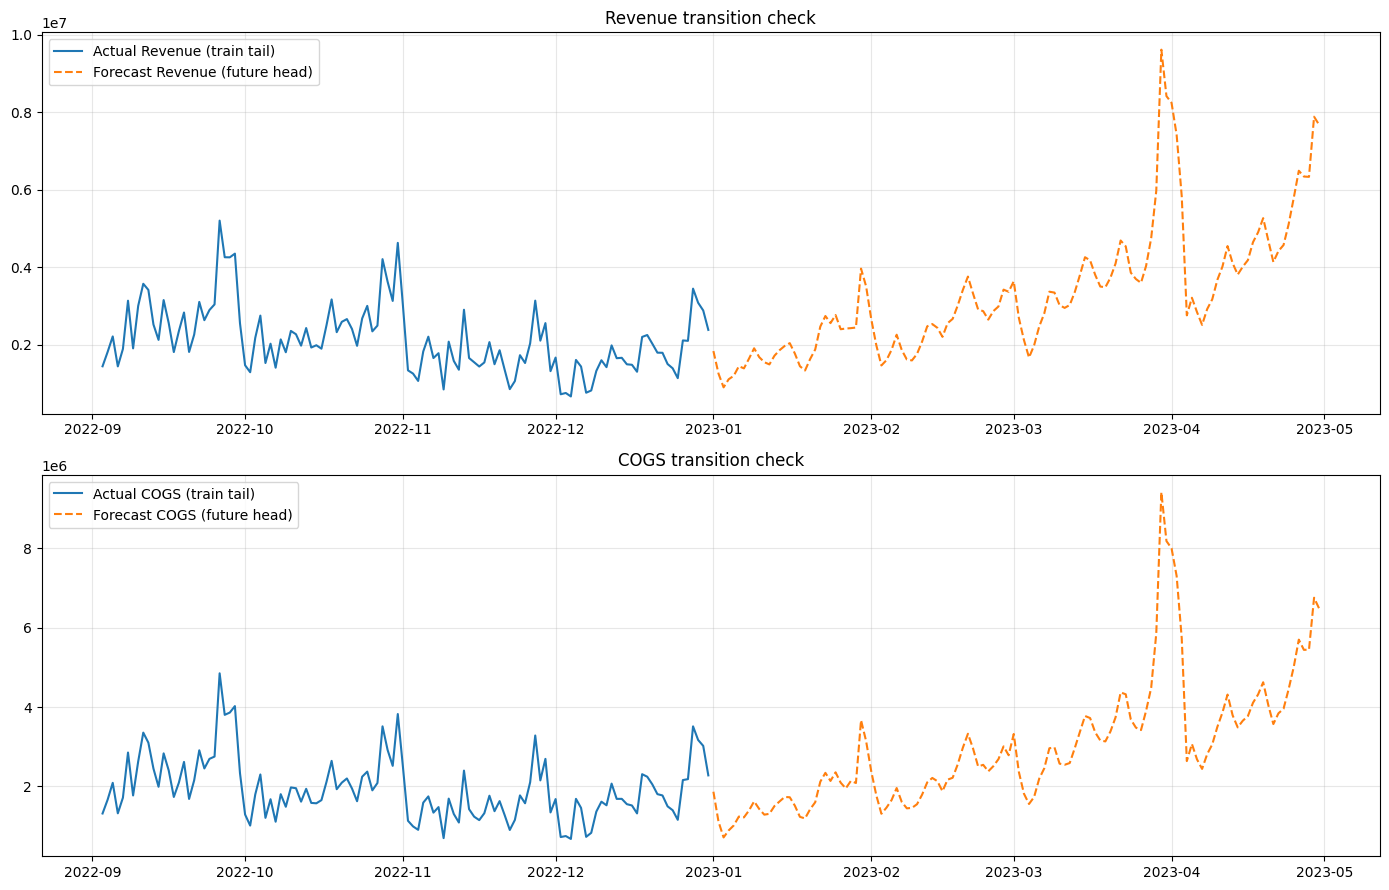

Notebook sync complete ✅
Chosen strategy: detrended
Submission file: ..\submission_v6_day5_max_optimized.csv
Backtest report: ..\scratch\day5_backtest_report.csv


In [11]:
tail_days = 120
future_dates = pd.to_datetime(submission["Date"])

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

axes[0].plot(df_train["Date"].tail(tail_days), df_train["Revenue"].tail(tail_days), label="Actual Revenue (train tail)")
axes[0].plot(future_dates.head(tail_days), submission["Revenue"].head(tail_days), linestyle="--", label="Forecast Revenue (future head)")
axes[0].set_title("Revenue transition check")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_train["Date"].tail(tail_days), df_train["COGS"].tail(tail_days), label="Actual COGS (train tail)")
axes[1].plot(future_dates.head(tail_days), submission["COGS"].head(tail_days), linestyle="--", label="Forecast COGS (future head)")
axes[1].set_title("COGS transition check")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Notebook sync complete ✅")
print(f"Chosen strategy: {chosen_strategy}")
print(f"Submission file: {OUTPUT_PATH}")
print(f"Backtest report: {BACKTEST_REPORT_PATH}")

## 7) One-click run (gọn cho demo/nộp bài)
Cell này chạy full pipeline trong 1 lần: backtest, chọn strategy, tạo submission, và (tuỳ chọn) vẽ biểu đồ.

In [12]:
def run_all_pipeline(strategy="auto", write_files=True, show_plot=True):
    if strategy == "auto":
        strategies_local = ["detrended", "hybrid", "legacy_recursive"]
    else:
        if strategy not in {"detrended", "hybrid", "legacy_recursive"}:
            raise ValueError("strategy phải là 'auto', 'detrended', 'hybrid' hoặc 'legacy_recursive'")
        strategies_local = [strategy]

    all_bt_local = []
    for st in strategies_local:
        bt_df = backtest_strategy(df_train, st, horizon=HORIZON)
        if not bt_df.empty:
            all_bt_local.append(bt_df)

    if not all_bt_local:
        raise RuntimeError("Không tạo được backtest result")

    backtest_report_local = pd.concat(all_bt_local, ignore_index=True)
    summary_local = (
        backtest_report_local.groupby("strategy", as_index=False)
        .agg(
            revenue_mae=("revenue_mae", "mean"),
            cogs_mae=("cogs_mae", "mean"),
            avg_mae=("avg_mae", "mean"),
        )
        .sort_values("avg_mae")
    )

    chosen_local = str(summary_local.iloc[0]["strategy"] if strategy == "auto" else strategy)
    rev_pred_local, cogs_pred_local = predict_by_strategy(df_train, df_sub["Date"], chosen_local)

    submission_local = df_sub[["Date"]].copy()
    submission_local["Revenue"] = np.clip(rev_pred_local, 0, None)
    submission_local["COGS"] = np.clip(cogs_pred_local, 0, None)
    submission_local["Date"] = submission_local["Date"].dt.strftime("%Y-%m-%d")

    if write_files:
        BACKTEST_REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
        OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
        backtest_report_local.to_csv(BACKTEST_REPORT_PATH, index=False)
        submission_local.to_csv(OUTPUT_PATH, index=False)

    if show_plot:
        tail_days_local = 120
        future_dates_local = pd.to_datetime(submission_local["Date"])

        fig_local, axes_local = plt.subplots(2, 1, figsize=(14, 9))

        axes_local[0].plot(df_train["Date"].tail(tail_days_local), df_train["Revenue"].tail(tail_days_local), label="Actual Revenue (train tail)")
        axes_local[0].plot(future_dates_local.head(tail_days_local), submission_local["Revenue"].head(tail_days_local), linestyle="--", label="Forecast Revenue (future head)")
        axes_local[0].set_title("Revenue transition check")
        axes_local[0].legend()
        axes_local[0].grid(alpha=0.3)

        axes_local[1].plot(df_train["Date"].tail(tail_days_local), df_train["COGS"].tail(tail_days_local), label="Actual COGS (train tail)")
        axes_local[1].plot(future_dates_local.head(tail_days_local), submission_local["COGS"].head(tail_days_local), linestyle="--", label="Forecast COGS (future head)")
        axes_local[1].set_title("COGS transition check")
        axes_local[1].legend()
        axes_local[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    print("✅ One-click run complete")
    print(f"Chosen strategy: {chosen_local}")
    print(f"Submission file: {OUTPUT_PATH}")
    print(f"Backtest report: {BACKTEST_REPORT_PATH}")

    return summary_local, submission_local, chosen_local


summary_1click, submission_1click, chosen_1click = run_all_pipeline(strategy="auto", write_files=True, show_plot=False)
display(summary_1click)
display(submission_1click.head(10))

✅ One-click run complete
Chosen strategy: detrended
Submission file: ..\submission_v6_day5_max_optimized.csv
Backtest report: ..\scratch\day5_backtest_report.csv


,strategy,revenue_mae,cogs_mae,avg_mae
0,detrended,6.402214e+05,5.378529e+05,5.890371e+05
1,hybrid,6.962813e+05,5.464829e+05,6.213821e+05
2,legacy_recursive,2.206410e+06,1.602442e+06,1.904426e+06


,Date,Revenue,COGS
0,2023-01-01,1.836245e+06,1.867629e+06
1,2023-01-02,1.254751e+06,1.115084e+06
2,2023-01-03,8.990289e+05,7.169861e+05
3,2023-01-04,1.107882e+06,8.937724e+05
4,2023-01-05,1.198277e+06,1.018936e+06
5,2023-01-06,1.445025e+06,1.242320e+06
6,2023-01-07,1.389383e+06,1.222110e+06
7,2023-01-08,1.642956e+06,1.397513e+06
8,2023-01-09,1.907871e+06,1.625206e+06
9,2023-01-10,1.679581e+06,1.433025e+06
